# Music Listener Persona Clustering

**Objective:** Discover listener personas from session depth, discovery, repeats, skips, playlist saves, and listening-hour diversity.

The deterministic demo data contains hidden generator profiles for post-hoc diagnostics. Those profiles are never supplied to the clustering algorithms.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Data contract and deterministic domain-shaped data


In [2]:
FEATURES = ["weekly_minutes", "unique_artists", "repeat_rate", "skip_rate", "playlist_saves", "active_hours"]
PROFILE_CENTERS = {
  "loyal_fans": [
    620,
    28,
    0.68,
    0.12,
    18,
    5
  ],
  "explorers": [
    540,
    96,
    0.22,
    0.31,
    35,
    12
  ],
  "casual": [
    120,
    18,
    0.36,
    0.42,
    4,
    3
  ],
  "playlist_curators": [
    710,
    72,
    0.4,
    0.18,
    82,
    9
  ]
}
rows = []
for profile, centers in PROFILE_CENTERS.items():
    centers = np.asarray(centers, dtype=float)
    scales = np.maximum(np.abs(centers) * 0.10, 0.08)
    samples = rng.normal(centers, scales, size=(125, len(FEATURES)))
    samples = np.maximum(samples, 0)
    for row in samples:
        rows.append({**dict(zip(FEATURES, row)), "generator_profile": profile})

data = pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
for column in FEATURES[:2]:
    missing_rows = rng.choice(data.index, size=8, replace=False)
    data.loc[missing_rows, column] = np.nan
print(f"Dataset shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
display(data.head().round(3))
display(data[FEATURES].describe().T.round(3))


Dataset shape: 500 rows × 7 columns


,weekly_minutes,unique_artists,repeat_rate,skip_rate,playlist_saves,active_hours,generator_profile
0,153.752,14.923,0.301,0.371,3.660,2.677,casual
1,579.434,29.198,0.665,0.146,18.651,5.660,loyal_fans
2,125.908,16.883,0.233,0.360,3.978,3.350,casual
3,540.325,100.304,0.313,0.442,36.084,12.707,explorers
4,649.210,26.506,0.647,0.229,16.127,3.794,loyal_fans


,count,mean,std,min,25%,50%,75%,max
weekly_minutes,492.0,496.149,235.295,90.763,153.426,572.895,667.172,889.765
unique_artists,492.0,53.051,32.685,12.514,21.916,33.421,82.312,118.175
repeat_rate,500.0,0.411,0.190,0.008,0.264,0.368,0.555,0.912
skip_rate,500.0,0.260,0.139,0.000,0.147,0.253,0.368,0.558
playlist_saves,500.0,34.842,29.959,3.034,11.485,25.077,47.123,103.095
active_hours,500.0,7.258,3.625,2.125,3.774,6.552,10.202,14.472


## 3. Robust preprocessing and cluster-count selection


In [3]:
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

preprocessor = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", RobustScaler())])
X = preprocessor.fit_transform(data[FEATURES])
selection_rows = []
for k in range(2, 7):
    labels = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE).fit_predict(X)
    selection_rows.append({"k": k, "silhouette": silhouette_score(X, labels), "davies_bouldin": davies_bouldin_score(X, labels)})
selection = pd.DataFrame(selection_rows)
display(selection.round(4))
best_k = int(selection.loc[selection["silhouette"].idxmax(), "k"])
print(f"Selected k={best_k} by maximum silhouette score.")


Selected k=4 by maximum silhouette score.


,k,silhouette,davies_bouldin
0,2,0.4916,0.6687
1,3,0.5927,0.6278
2,4,0.6640,0.5311
3,5,0.5746,0.9451
4,6,0.4870,1.1704


## 4. Compare algorithms and retain the clearer solution


In [4]:
kmeans = KMeans(n_clusters=best_k, n_init=40, random_state=RANDOM_STATE)
kmeans_labels = kmeans.fit_predict(X)
hierarchical_labels = AgglomerativeClustering(n_clusters=best_k, linkage="ward").fit_predict(X)

comparison = pd.DataFrame([
    {"model": "K-Means", "silhouette": silhouette_score(X, kmeans_labels), "davies_bouldin": davies_bouldin_score(X, kmeans_labels)},
    {"model": "Agglomerative", "silhouette": silhouette_score(X, hierarchical_labels), "davies_bouldin": davies_bouldin_score(X, hierarchical_labels)},
])
display(comparison.round(4))
labels = kmeans_labels if comparison.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True]).iloc[0]["model"] == "K-Means" else hierarchical_labels
selected_model = "K-Means" if np.array_equal(labels, kmeans_labels) else "Agglomerative"
data["cluster"] = labels
print(f"Selected solution: {selected_model}")


Selected solution: K-Means


,model,silhouette,davies_bouldin
0,K-Means,0.664,0.5311
1,Agglomerative,0.664,0.5311


## 5. Profile and visualize the discovered groups


Retrospective ARI against hidden generator profiles: 1.0000


,records,weekly_minutes,unique_artists,repeat_rate,skip_rate,playlist_saves,active_hours
cluster,,,,,,,
0,125,614.789,27.805,0.683,0.122,17.917,4.945
1,125,541.929,96.163,0.212,0.314,35.099,12.033
2,125,715.498,71.794,0.398,0.188,82.392,9.095
3,125,117.606,17.874,0.352,0.417,3.962,2.959


cluster,0,1,2,3,All
generator_profile,,,,,
casual,0,0,0,125,125
explorers,0,125,0,0,125
loyal_fans,125,0,0,0,125
playlist_curators,0,0,125,0,125
All,125,125,125,125,500


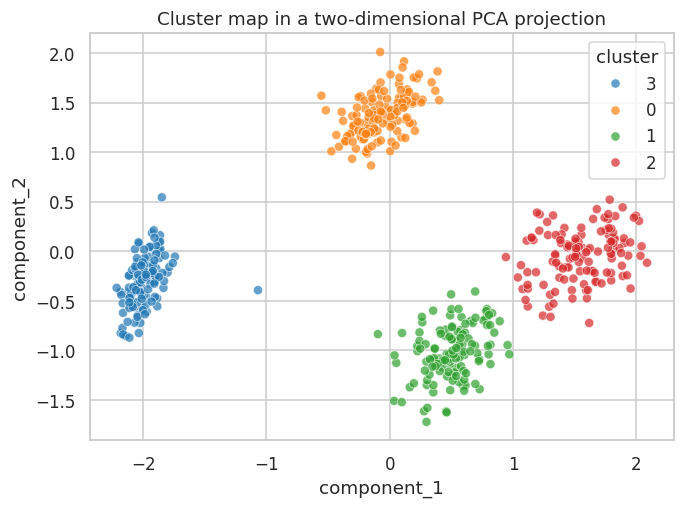

In [5]:
from sklearn.decomposition import PCA

profiles = data.groupby("cluster")[FEATURES].mean().round(3)
profiles.insert(0, "records", data.groupby("cluster").size())
display(profiles)
display(pd.crosstab(data["generator_profile"], data["cluster"], margins=True))
print(f"Retrospective ARI against hidden generator profiles: {adjusted_rand_score(data['generator_profile'], data['cluster']):.4f}")

projection = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
plot_data = pd.DataFrame({"component_1": projection[:, 0], "component_2": projection[:, 1], "cluster": data["cluster"].astype(str)})
sns.scatterplot(data=plot_data, x="component_1", y="component_2", hue="cluster", palette="tab10", alpha=0.7)
plt.title("Cluster map in a two-dimensional PCA projection")
plt.tight_layout()
plt.show()


## 6. Stability and assignment example


In [6]:
alternate = KMeans(n_clusters=best_k, n_init=40, random_state=7).fit_predict(X)
print(f"K-Means stability across seeds (ARI): {adjusted_rand_score(kmeans_labels, alternate):.4f}")
if selected_model == "K-Means":
    example = data[FEATURES].median().to_frame().T
    predicted = int(kmeans.predict(preprocessor.transform(example))[0])
    display(example.round(3).assign(predicted_cluster=predicted))
else:
    print("Agglomerative clustering has no native out-of-sample predict method; production assignment would use centroids or a trained surrogate.")


K-Means stability across seeds (ARI): 1.0000


,weekly_minutes,unique_artists,repeat_rate,skip_rate,playlist_saves,active_hours,predicted_cluster
0,572.895,33.421,0.368,0.253,25.077,6.552,0


## 7. Findings and limitations

- Multiple internal metrics and a seed-stability check are used because clustering has no single accuracy measure.
- Hidden generator profiles provide only a retrospective pipeline check.
- Production interpretation requires domain validation, drift monitoring, and explicit rules for acting on segments.
